# Data understanding over the original datasets

In this notebook we examine the relationships between features that are common between the two original datasets (nad the agumented one). Particularly we chose to inspect only the single value features and to distinguish between continuous and descret, for which different inspection instruments are required.

Below are defined the functions later called for each dataset:
- `_load_dataset(*)` loads the `.root` files and returns a Pandas DataFrame;
- `_correlation_heatmap(*)` shows the Pearson and Spearman correlation heatmap between continuous features only;
- `_scatterplot_MET(*)` shows the relationship between the features `MET_pt` and `GenMET_pt`;
- `_data_distributions(*)` shows the distributions via histograms of the continuous features;
- `_boxplots(*)` shows the boxplot for each continuous feature to indentify outliers;
- `_data_barplots(*)` shows the barplots for each descrete feature, with `nJet` and `nGenJet` showed alongside.

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot

In [22]:
DATASETS = {
    "ZZTo2L2Nu": "../SkimmedDatasets/skimmed_ZZTo2L2Nu.root",
    "HToAATo2Mu2B": "../SkimmedDatasets/skimmed_HToAATo2Mu2B.root",
    "augmented_HToAATo2Mu2B": "../SkimmedDatasets/skimmed_augmented_HToAATo2Mu2B.root",
}

TREE_NAME = "Events"

FLOAT_FEATURES = [
    "MET_pt", "MET_phi", "MET_covXX", "MET_covXY", "MET_covYY",
    "MET_significance", "GenMET_pt",
    "PV_chi2", "PV_score", "PV_x", "PV_y", "PV_z",
]
INT_FEATURES = ["nSV", "nElectron", "nMuon", "nJet", "nGenJet"]

PALETTE = ["royalblue", "orangered", "darkgreen"]

In [23]:
def _load_dataset(path, tree_name):
    """
        Loads branches from a .root file and returns a Pandas DataFrame.
    """
    all_branches = FLOAT_FEATURES + INT_FEATURES
    with uproot.open(f"{path}:{tree_name}") as tree:
        df = tree.arrays(all_branches, library="pd")

    # Explicit casting
    df[FLOAT_FEATURES] = df[FLOAT_FEATURES].astype(np.float64)
    df[INT_FEATURES]   = df[INT_FEATURES].astype(np.int64)
    return df

In [24]:
def _correlation_heatmap(df, label, method="pearson"):
    corr = df[FLOAT_FEATURES].replace([np.inf, -np.inf], np.nan).corr(method=method)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr,
        annot=True, fmt=".2f",
        cmap="coolwarm", linewidths=0.5, linecolor='gray', annot_kws={"size": 8})
    plt.title(f"{method} correlation heatmap - {label}")
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()
    return

In [25]:
def _scatterplot_MET(df, label, color):
    x = df["MET_pt"]
    y = df["GenMET_pt"]
    mask = np.isfinite(x) & np.isfinite(y)

    # Statistics
    print(f"Statistics for dataset {label}:")
    print(f"    MET_pt:\n{x.describe()}")
    print(f"    GenMET_pt:\n{y.describe()}")

    plt.figure(figsize=(10, 8))
    plt.scatter(
        x[mask], y[mask], s=4, alpha=0.35,
        color=color, label=label, rasterized=True)

    # y = x line
    lim_max = plt.xlim()[1]
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(f"GenMET vs MET - {label}", fontsize=13, fontweight="bold")
    plt.xlabel("MET_pt [GeV]", fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.plot()
    return

In [26]:
def _data_distributions(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()
        ax.hist(vals, bins=100, density=True, histtype="step",
                linewidth=1.5, color=color, label=label)
        ax.set_xlabel(feat, fontsize=9)
        ax.set_ylabel("Density", fontsize=8)
        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.legend(fontsize=7)
        ax.grid(alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Distributions for float features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [27]:
def _boxplots(df, label, color):
    n_feat = len(FLOAT_FEATURES)
    ncols = 3
    nrows = (n_feat + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    print(f"Outliers — {label}")

    for idx, feat in enumerate(FLOAT_FEATURES):
        ax = axes[idx]
        vals = df[feat].replace([np.inf, -np.inf], np.nan).dropna()

        # IQR
        q1, q3 = vals.quantile(0.25), vals.quantile(0.75)
        IQR = q3 - q1
        lower, upper = q1 - 1.5 * IQR, q3 + 1.5 * IQR
        n_outliers = ((vals < lower) | (vals > upper)).sum()
        pct = n_outliers / len(vals) * 100
        print(f"  {feat:<20} {n_outliers:>6} outliers ({pct:.2f}%)")

        bp = ax.boxplot(vals, patch_artist=True, vert=True,
                        flierprops=dict(marker=".", markersize=2, alpha=0.3,
                                        markerfacecolor=color, markeredgecolor=color),
                        medianprops=dict(color="black", linewidth=1.5),
                        boxprops=dict(facecolor=color, alpha=0.5),
                        whiskerprops=dict(color=color),
                        capprops=dict(color=color))

        ax.set_title(feat, fontsize=9, fontweight="bold")
        ax.set_ylabel(feat, fontsize=8)
        ax.set_xticks([])
        ax.text(0.97, 0.97, f"{n_outliers} outliers\n({pct:.1f}%)",
                transform=ax.transAxes, fontsize=7,
                verticalalignment="top", horizontalalignment="right",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.7))
        ax.grid(axis="y", alpha=0.25)

    for j in range(idx + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Boxplots — {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

In [28]:
def _data_barplots(df, label, color):
    solo_features = ["nSV", "nElectron", "nMuon"]
    n_plots = len(solo_features) + 1
    ncols = 2
    nrows = (n_plots + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 5 * nrows))
    axes = axes.flatten()

    def draw_bar(ax, feat):
        vals = df[feat].dropna()
        bins = np.arange(int(vals.min()), int(vals.max()) + 2) - 0.5
        centers = (bins[:-1] + bins[1:]) / 2
        counts, _ = np.histogram(vals, bins=bins)
        ax.bar(centers, counts, width=0.8, color=color, label=label, alpha=0.85)

    for idx, feat in enumerate(solo_features):
        ax = axes[idx]
        draw_bar(ax, feat)
        ax.set_xlabel(feat, fontsize=10)
        ax.set_ylabel("Counts", fontsize=10)
        ax.set_title(feat, fontsize=11, fontweight="bold")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3)

    # nJet vs nGenJet - combined plot
    ax_pair = axes[len(solo_features)]
    all_jet = pd.concat([df["nJet"], df["nGenJet"]]).dropna()
    bins = np.arange(int(all_jet.min()), int(all_jet.max()) + 2) - 0.5
    centers = (bins[:-1] + bins[1:]) / 2
    width = 0.8 / 2

    for i, (feat, hatch, alpha) in enumerate([("nJet", "", 0.75), ("nGenJet", "//", 0.45)]):
        counts, _ = np.histogram(df[feat].dropna(), bins=bins)
        offset = (i - 1 + 0.5) * width
        ax_pair.bar(centers + offset, counts, width=width * 0.9,
                    color=color, alpha=alpha, hatch=hatch,
                    edgecolor="grey", linewidth=0.4,
                    label=f"{label} — {feat}")
        x_ticks = np.arange(int(all_jet.min()), int(all_jet.max()) + 1)
        ax_pair.set_xticks(x_ticks)

    ax_pair.set_xlabel("n", fontsize=10)
    ax_pair.set_ylabel("Counts", fontsize=10)
    ax_pair.set_title("nJet vs nGenJet", fontsize=11, fontweight="bold")
    ax_pair.legend(fontsize=7, ncol=2)
    ax_pair.grid(axis="y", alpha=0.3)

    for j in range(len(solo_features) + 1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"Barplots for integer features - {label}", fontsize=14, fontweight="bold", y=1.01)
    fig.tight_layout()
    plt.show()
    return

---

## ZZTo2L2Nu dataset

In this event a pair of Z bosons decays into a pair of leptons and a pair of neutrinos. The MET values are primarily due to the neutrinos, which are invisible to the detector: MET is the only observable that can indirectly signal their presence.

Given the underlying physics of this proccess, we expect:
- higher values of `MET_pt`;
- events containing either 2 electrons or 2 muons;
- no significant jet activity (jets that do appear are likely due to secondary processes);
- no significant number of secondary vertices.


This dataset was chosen because the physics process is well understood and the observed MET is most likely genuine, i.e. directly attributable to the neutrinos produced in the decay, making it a reliable starting point for the analysis.

In [29]:
label = list(DATASETS.items())[0][0]
path = DATASETS.get("ZZTo2L2Nu")
color = PALETTE[0]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset ZZTo2L2Nu:
    17 features x 168000 events


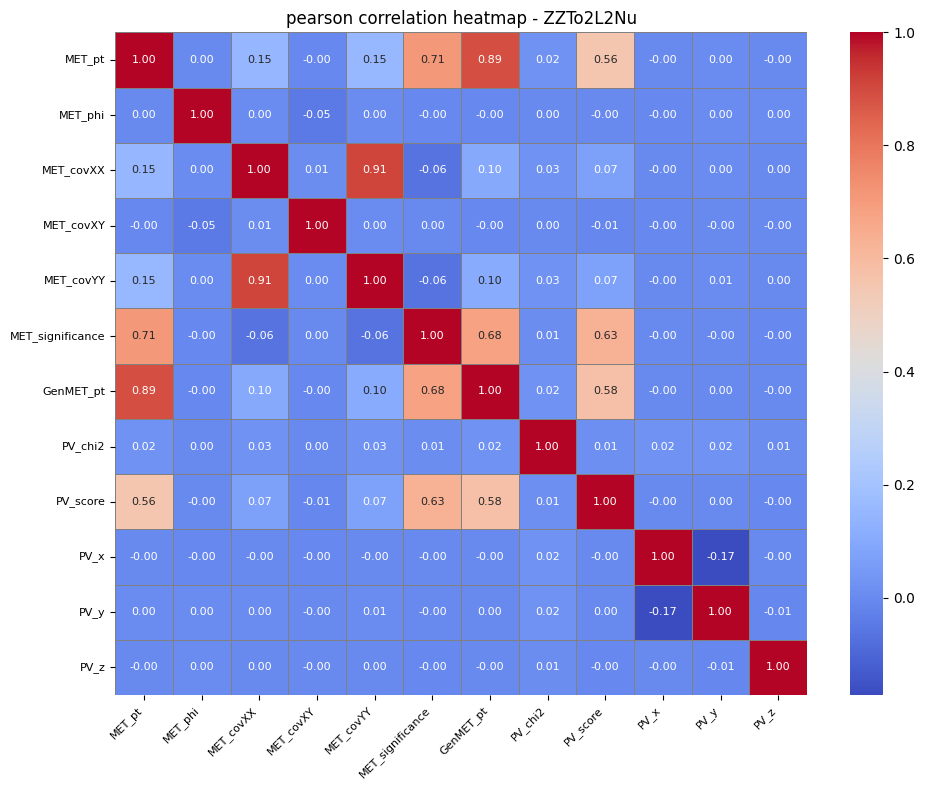

In [30]:
_correlation_heatmap(df, label)

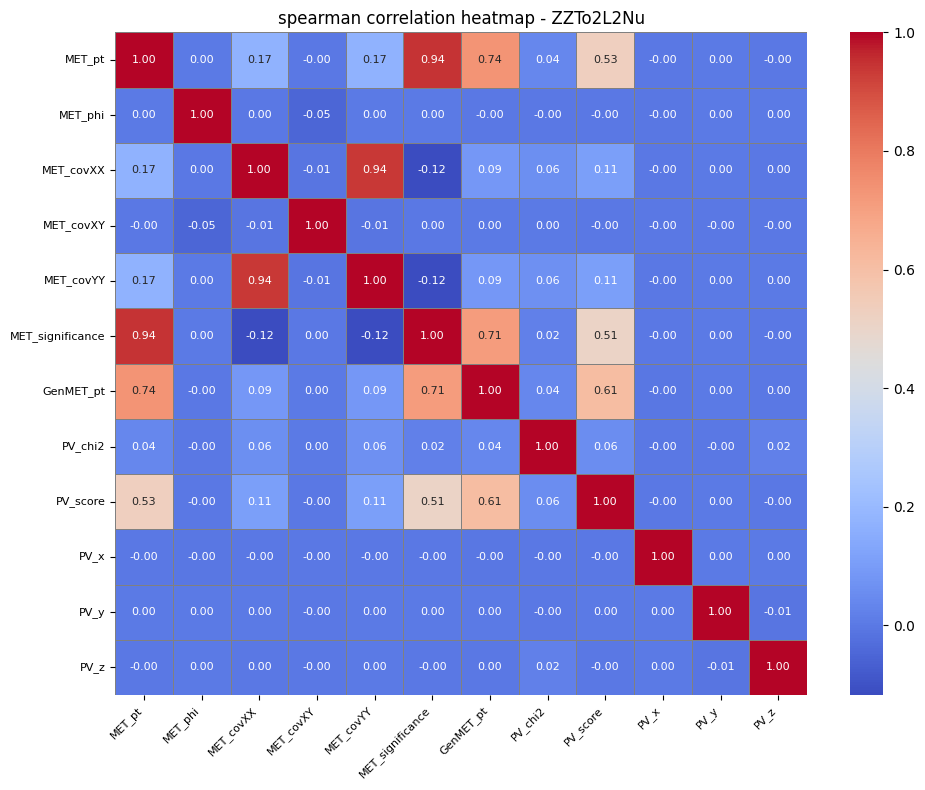

In [31]:
_correlation_heatmap(df, label, method="spearman")

Statistics for dataset ZZTo2L2Nu:
    MET_pt:
count    168000.000000
mean         54.377074
std          46.725715
min           0.134062
25%          24.884356
50%          42.397621
75%          69.137030
max        1064.584229
Name: MET_pt, dtype: float64
    GenMET_pt:
count    168000.000000
mean         46.836781
std          46.413196
min           0.024750
25%          17.078125
50%          34.031250
75%          60.718750
max         955.000000
Name: GenMET_pt, dtype: float64


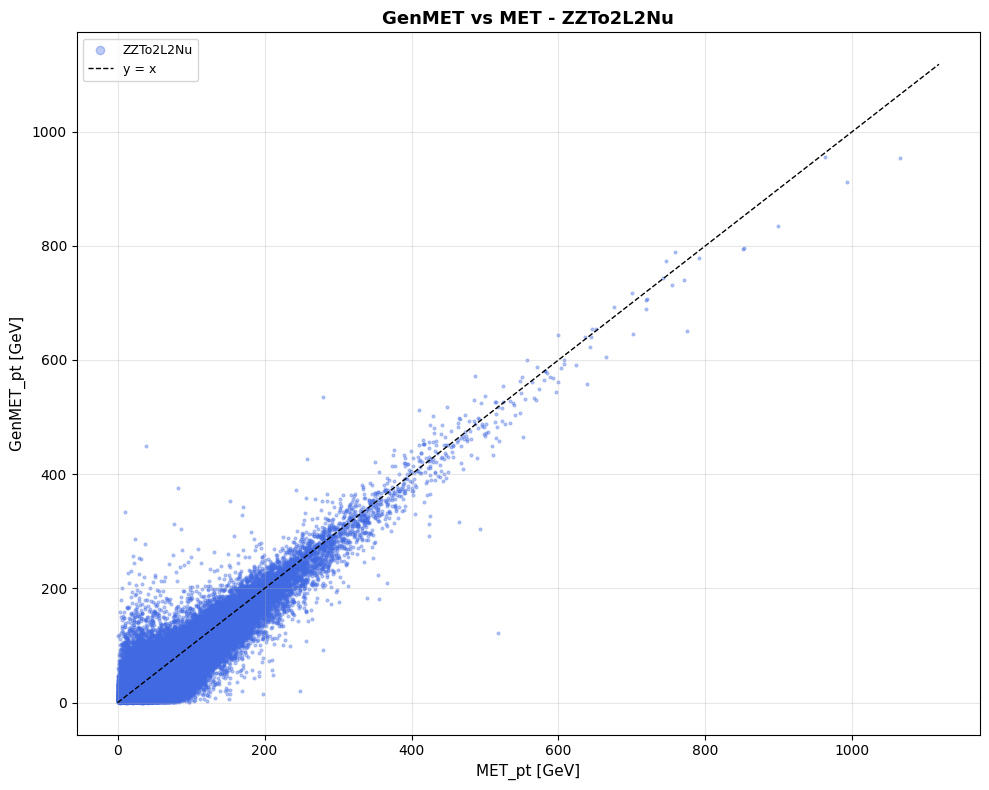

In [32]:
_scatterplot_MET(df, label=label, color=color)

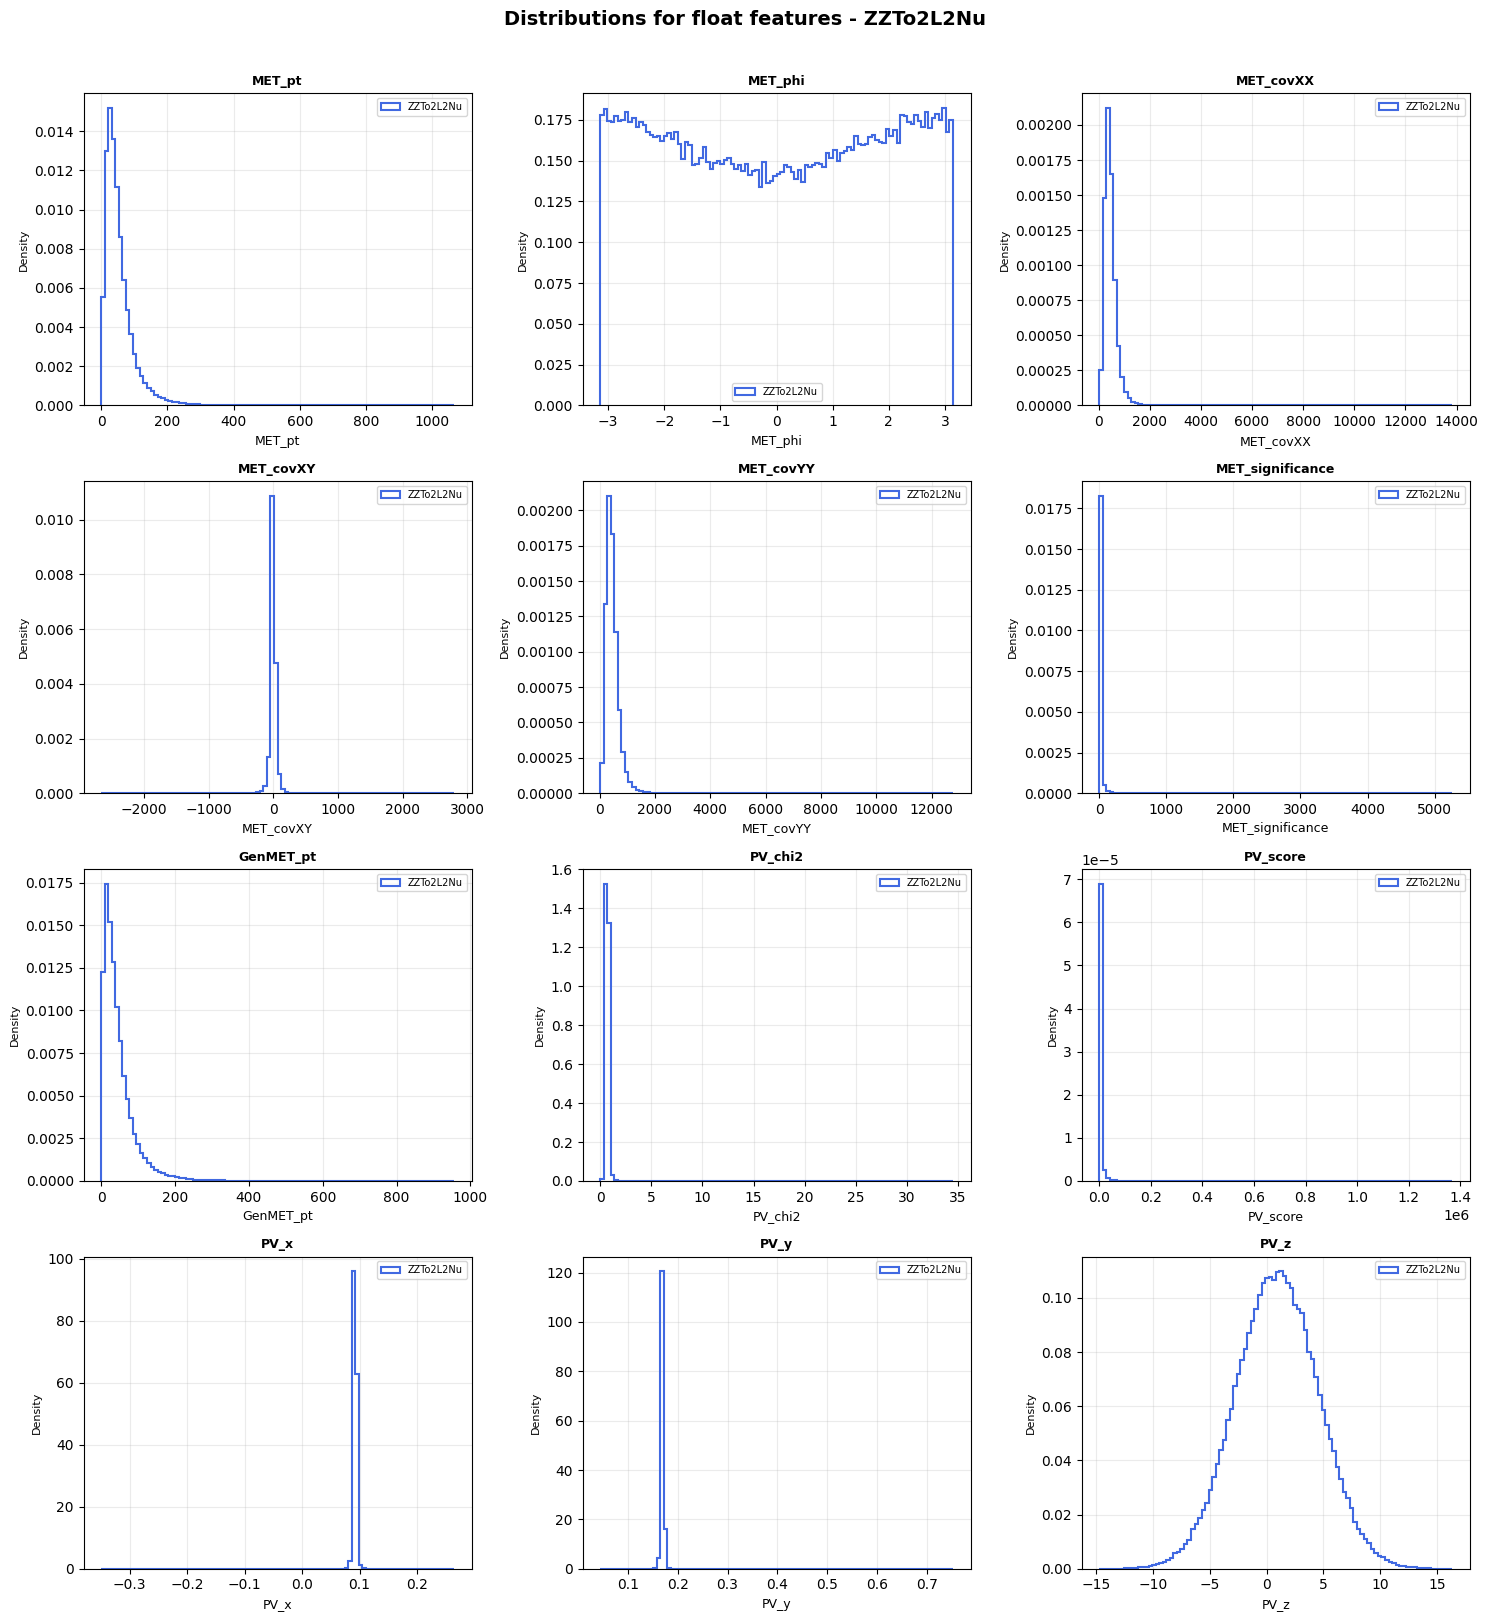

In [33]:
_data_distributions(df, label=label, color=color)

Outliers — ZZTo2L2Nu
  MET_pt                 8875 outliers (5.28%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX              5810 outliers (3.46%)
  MET_covXY             18397 outliers (10.95%)
  MET_covYY              5922 outliers (3.52%)
  MET_significance      17518 outliers (10.43%)
  GenMET_pt              9224 outliers (5.49%)
  PV_chi2                5164 outliers (3.07%)
  PV_score              16610 outliers (9.89%)
  PV_x                   5303 outliers (3.16%)
  PV_y                   5506 outliers (3.28%)
  PV_z                   1146 outliers (0.68%)


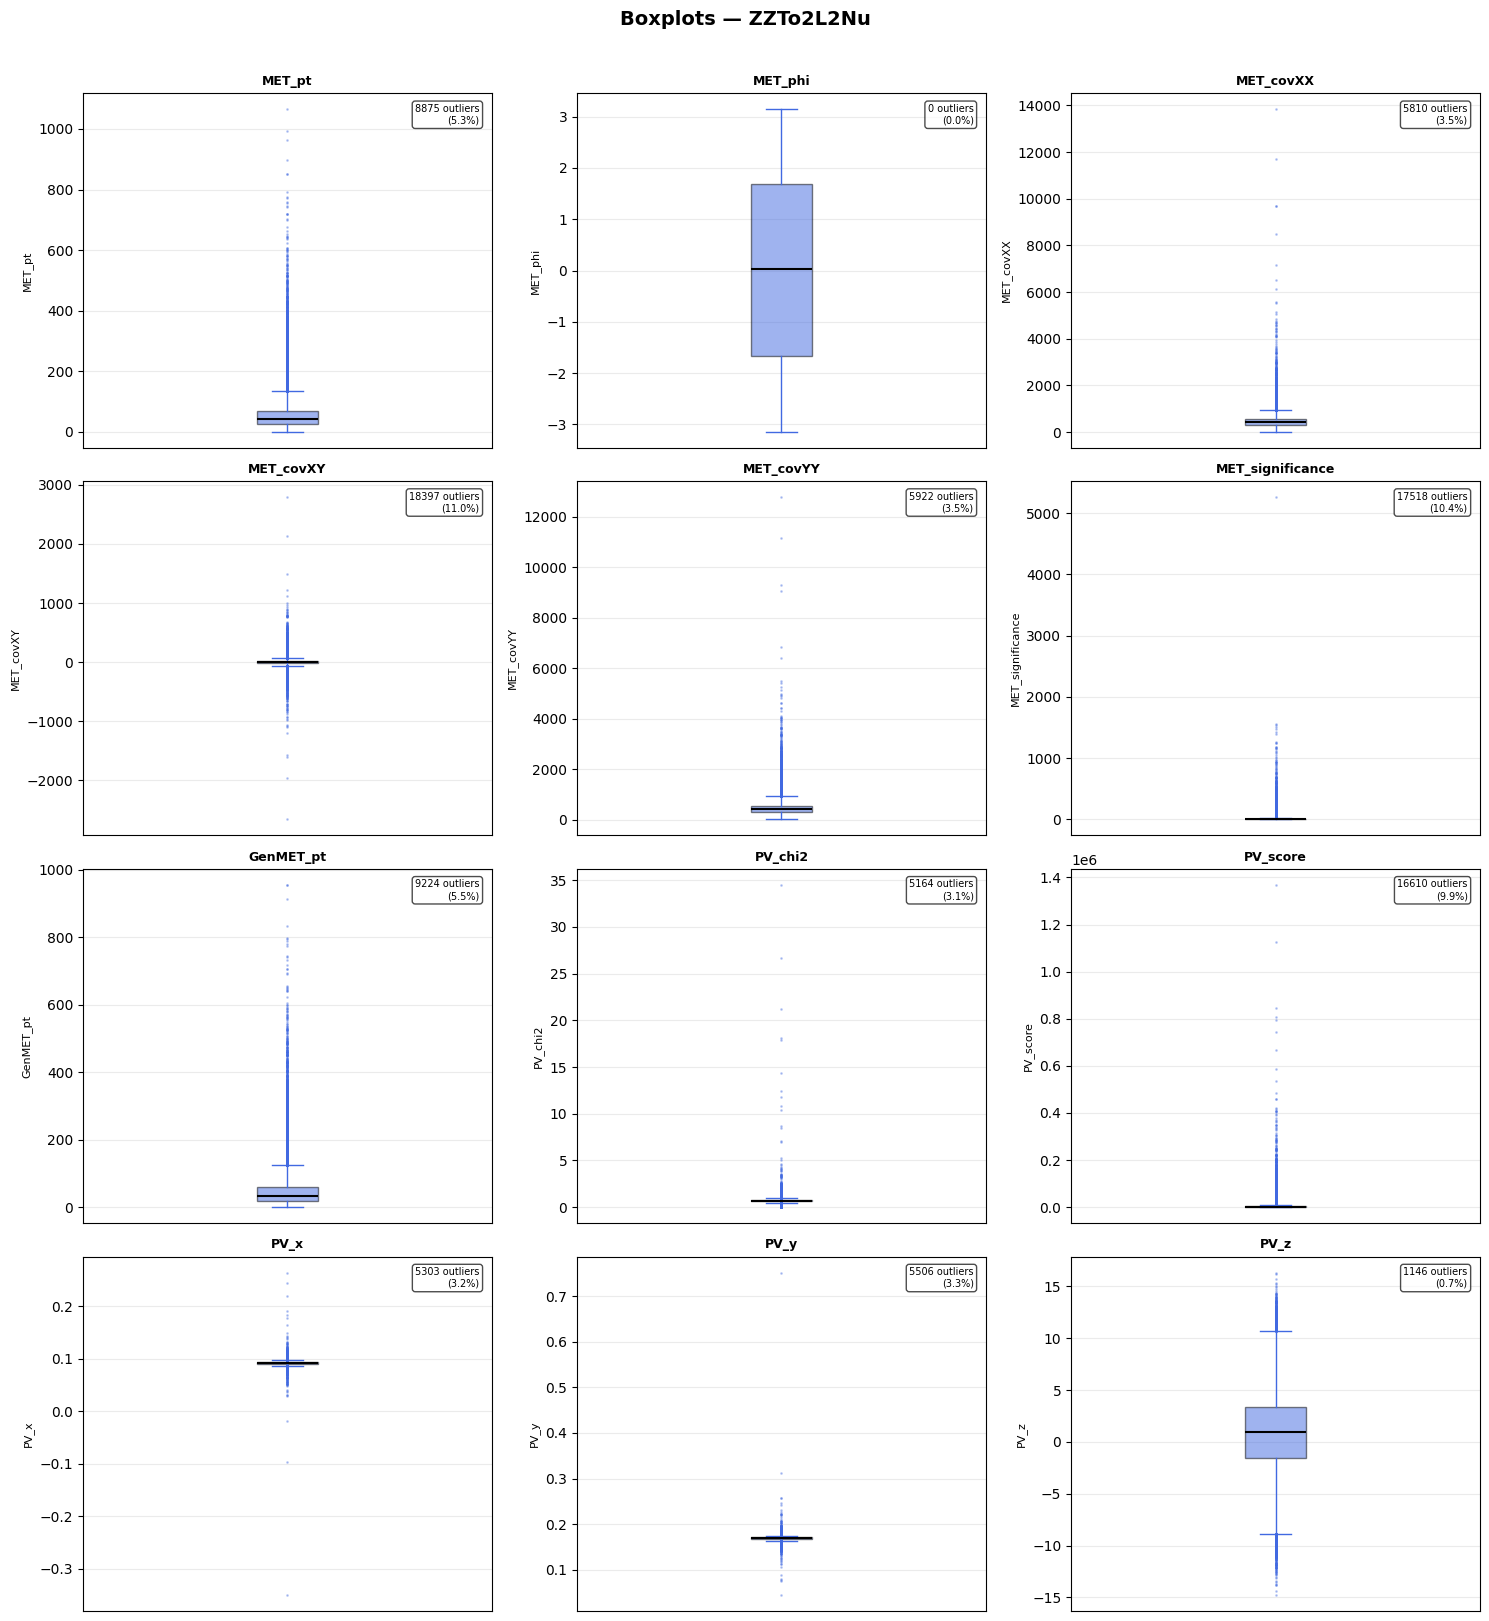

In [34]:
_boxplots(df, label=label, color=color)

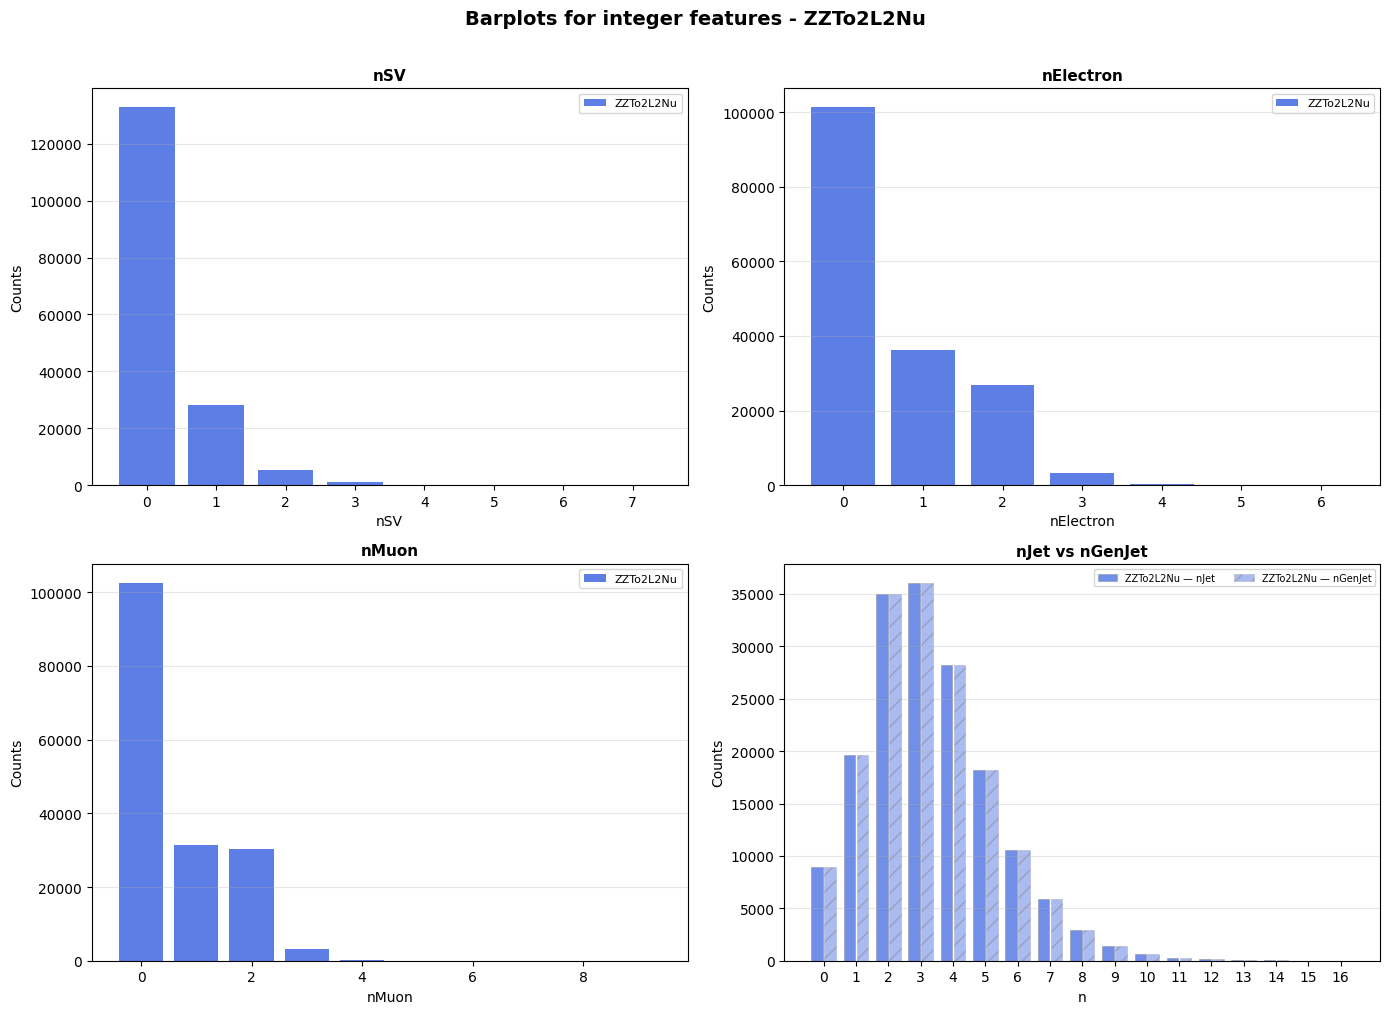

In [35]:
_data_barplots(df, label=label, color=color)

In [36]:
print(df["nMuon"].value_counts())
print(df["nElectron"].value_counts())

nMuon
0    102587
1     31526
2     30221
3      3289
4       328
5        42
6         5
9         1
7         1
Name: count, dtype: int64
nElectron
0    101310
1     36374
2     26748
3      3200
4       336
5        31
6         1
Name: count, dtype: int64


As shown, a fraction of events records either more than two or a single lepton, which is inconsistent with the signal. As expected, the number of events with exactly two electrons is approximately equal to those with exactly two muons, in agreement with theory: both decay modes have the same branching ratio (~50%).

All other observations are a direct consequence of the event composition, confirming that a cleaning step is necessary to remove events that do not match the expected signal signature.

---

## HToAATo2Mu2B Dataset

In this process, a Higgs boson decays into a pair of light pseudoscalar particles, each of which subsequently decays into either a pair of muons or a pair of b-quarks.

From this dataset we expect:
- lower values of `MET_pt`, since neutrinos are not part of the decay chain and any observed MET is primarily due to pile-up and detector effects;
- events containing pairs of muons and b-jets;
- a significant number of secondary vertices, arising from the displaced decays of the b-hadrons.

This dataset, while well motivated, presents a greater challenge for machine learning. The decay chain involves a relatively large number of final state particles, each contributing its own set of observable features. Unlike the ZZTo2L2Nu case, where MET has a clear physical origin, here the MET signal is weak and dominated by instrumental effects, making it harder for the model to find a meaningful pattern. This makes the HToAATo2Mu2B process a useful stress test for evaluating the robustness and generalization of the trained model.

In [37]:
label = list(DATASETS.items())[1][0]
path = DATASETS.get("HToAATo2Mu2B")
color = PALETTE[1]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset HToAATo2Mu2B:
    17 features x 200000 events


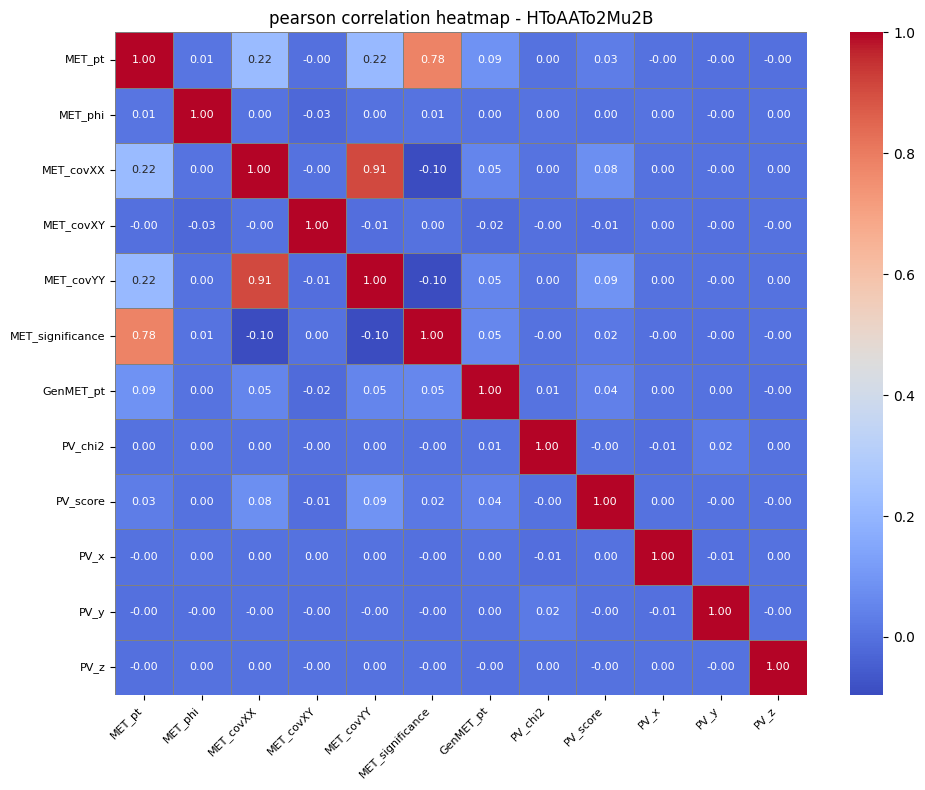

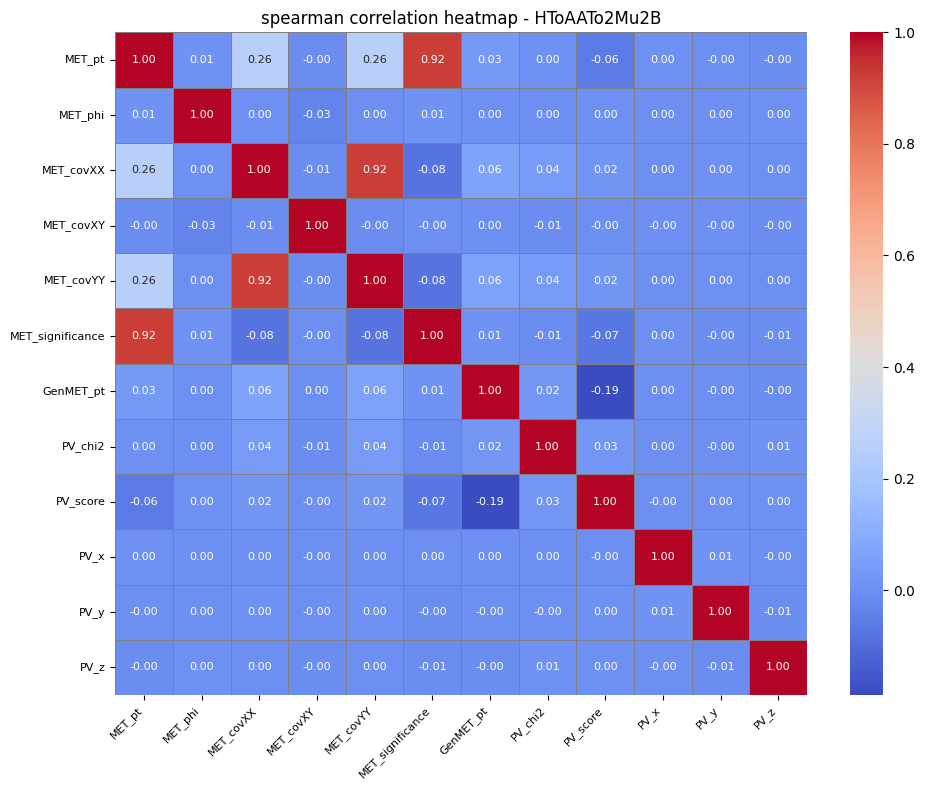

Statistics for dataset HToAATo2Mu2B:
    MET_pt:
count    200000.000000
mean         28.771740
std          17.961229
min           0.060027
25%          15.836837
50%          25.457947
75%          37.923629
max         358.427490
Name: MET_pt, dtype: float64
    GenMET_pt:
count    2.000000e+05
mean     4.262918e+00
std      6.550319e+00
min      1.417616e-14
25%      3.250534e-09
50%      1.532227e+00
75%      6.105469e+00
max      2.945000e+02
Name: GenMET_pt, dtype: float64


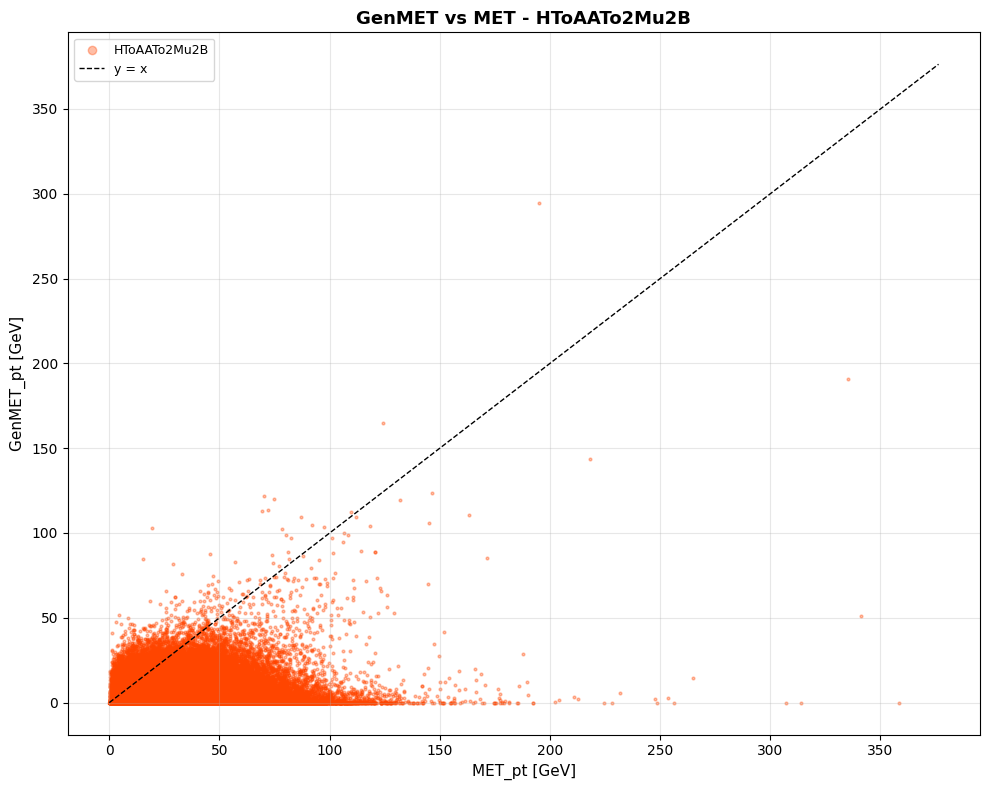

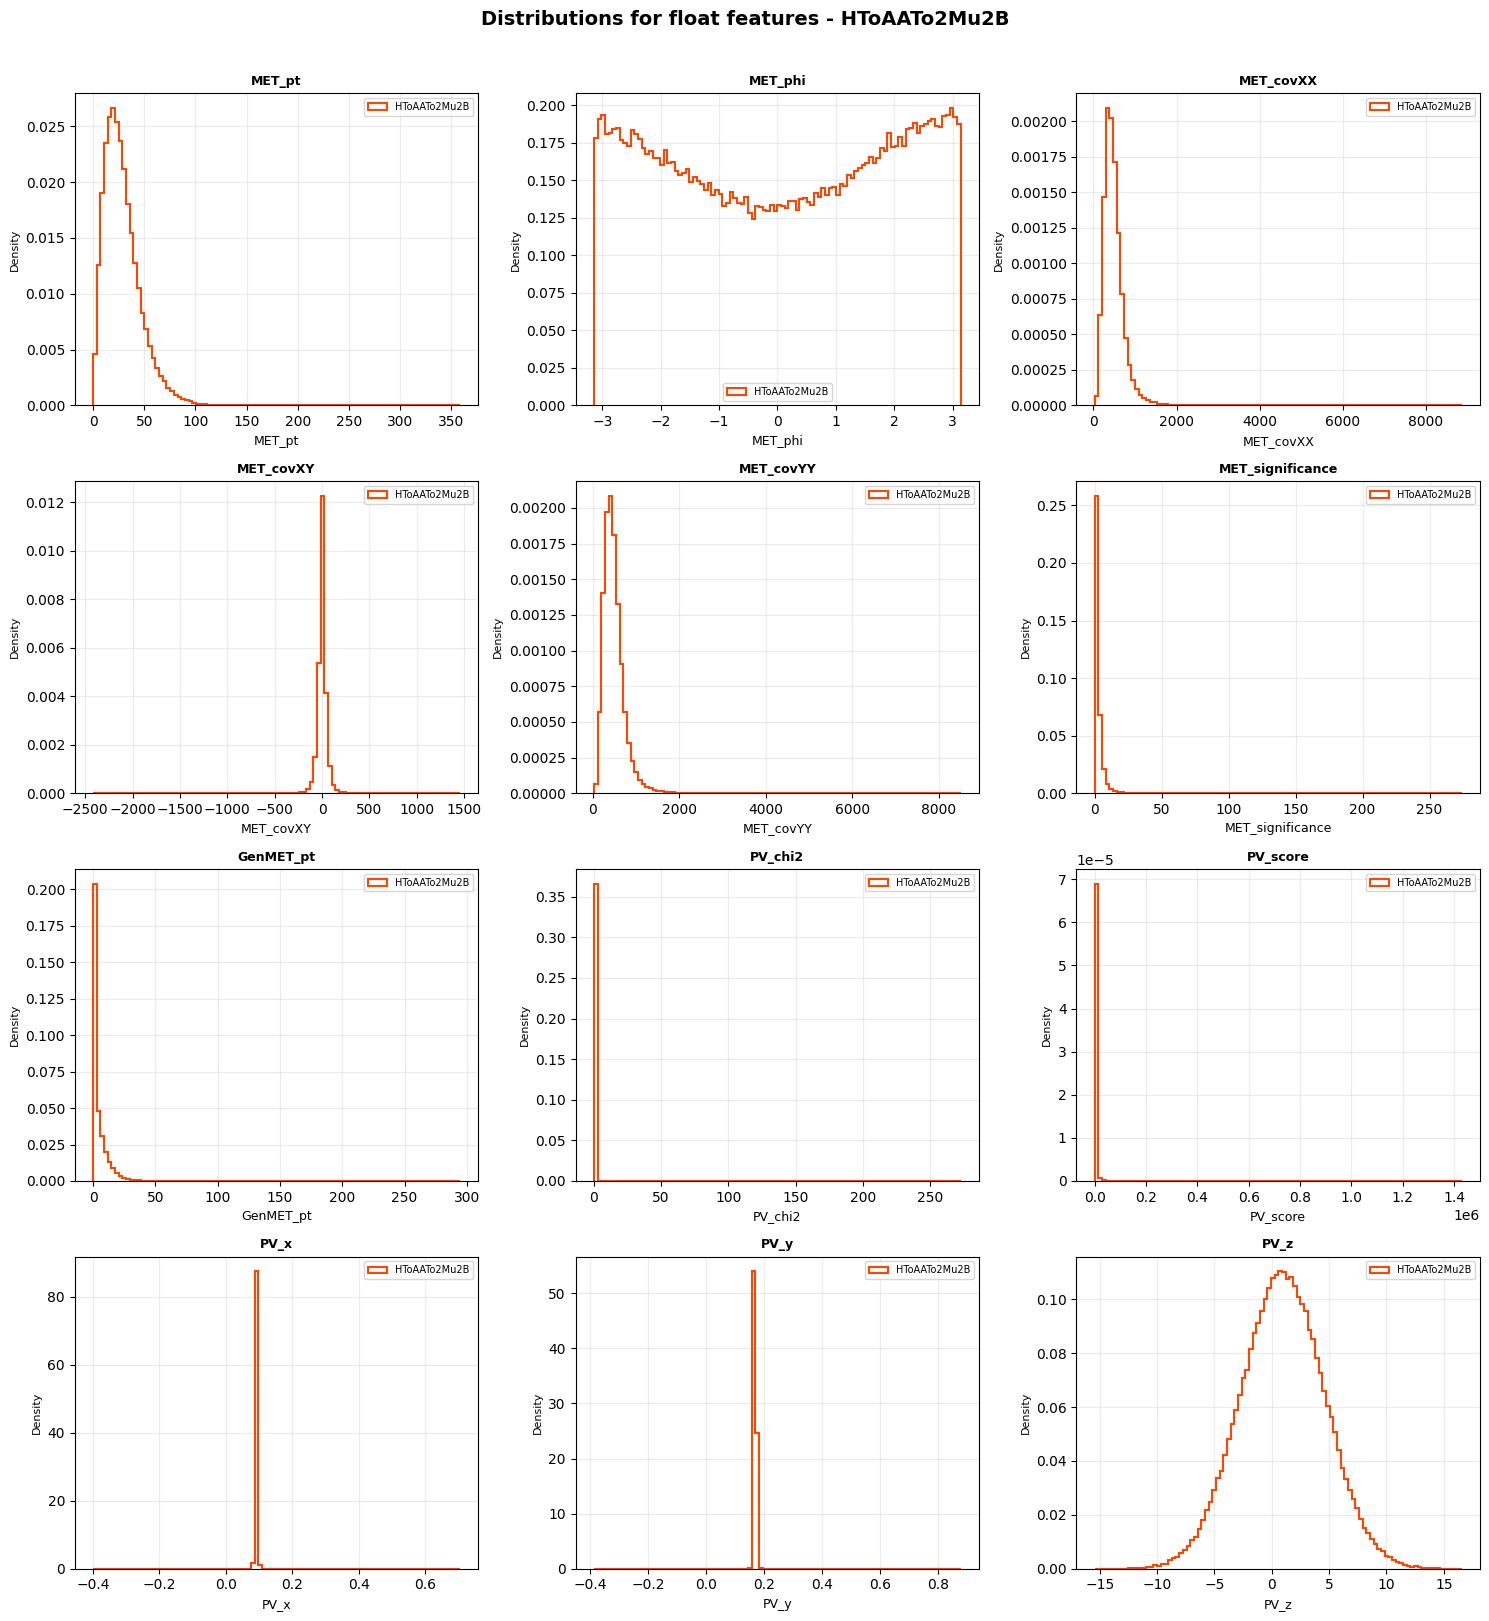

Outliers — HToAATo2Mu2B
  MET_pt                 5393 outliers (2.70%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX              7180 outliers (3.59%)
  MET_covXY             15720 outliers (7.86%)
  MET_covYY              7316 outliers (3.66%)
  MET_significance      13876 outliers (6.94%)
  GenMET_pt             13044 outliers (6.52%)
  PV_chi2                6531 outliers (3.27%)
  PV_score               7397 outliers (3.70%)
  PV_x                   7626 outliers (3.81%)
  PV_y                   6652 outliers (3.33%)
  PV_z                   1363 outliers (0.68%)


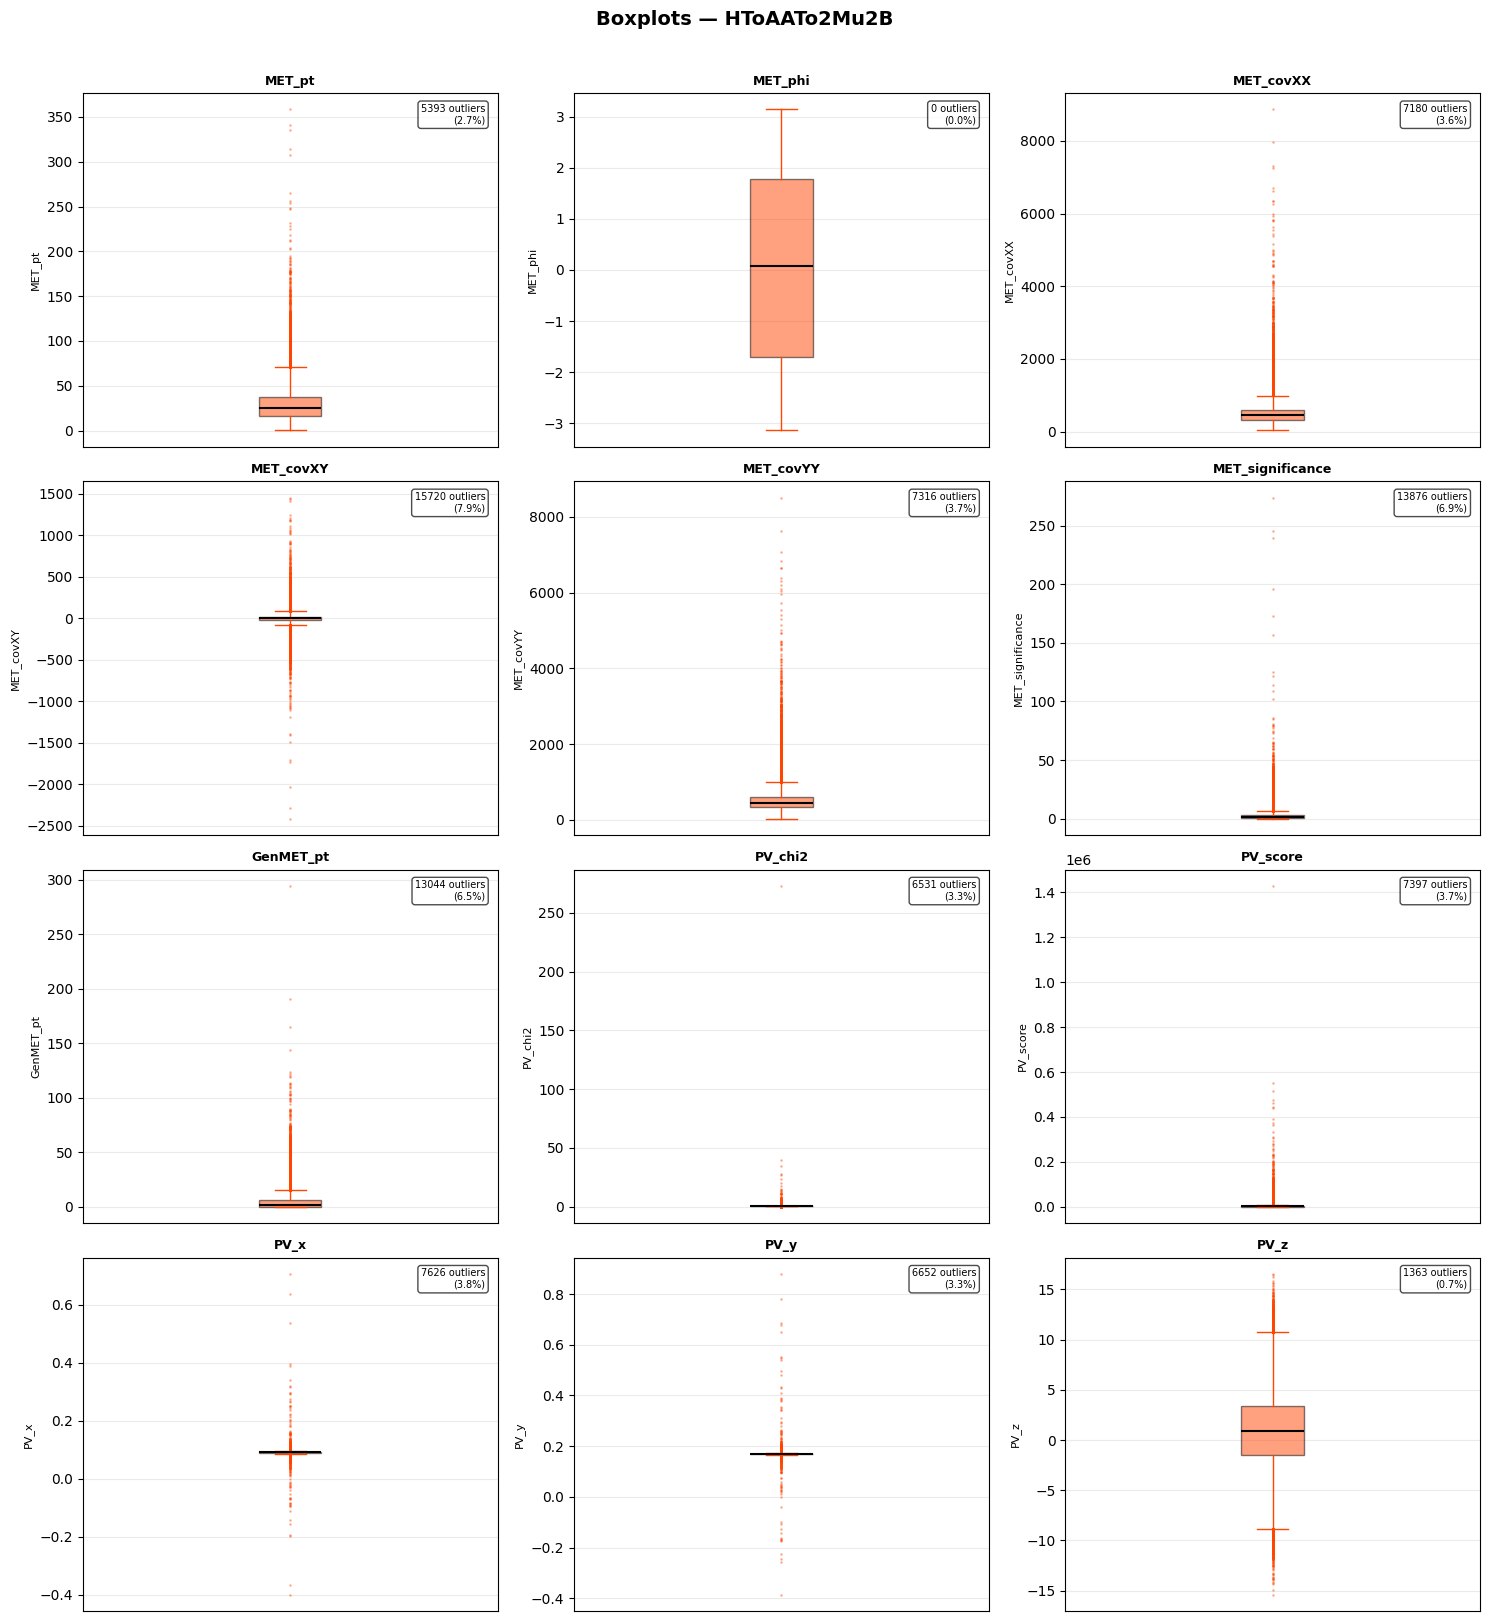

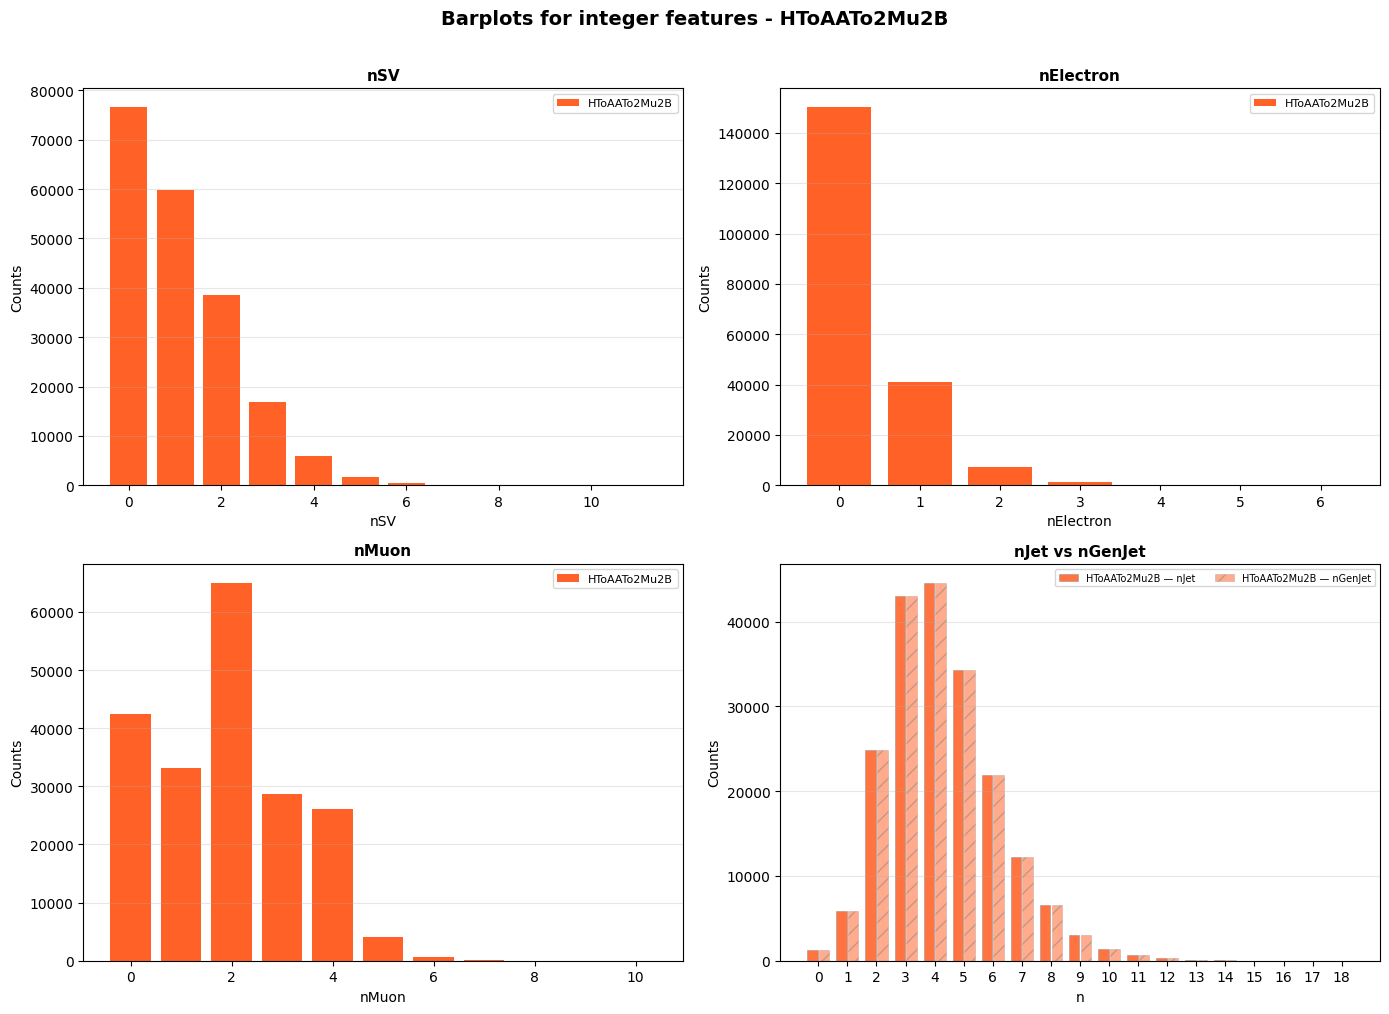

In [38]:
_correlation_heatmap(df, label)

_correlation_heatmap(df, label, method="spearman")

_scatterplot_MET(df, label=label, color=color)

_data_distributions(df, label=label, color=color)

_boxplots(df, label=label, color=color)

_data_barplots(df, label=label, color=color)

As visible in the `MET_pt vs GenMET_pt` plot, the reconstructed MET poorly tracks the generator level MET for this process, confirming that the detector is not sensitive enough to the actual missing energy involved. This motivates the use of additional, more discriminating features rather than relying on `MET_pt` alone.

---

# HToAATo2Mu2B augmented dataset


In [39]:
label = list(DATASETS.items())[2][0]
path = DATASETS.get("augmented_HToAATo2Mu2B")
color = PALETTE[2]

df = _load_dataset(path, TREE_NAME)
print(f"Dataset {label}:")
print(f"    {df.shape[1]} features x {df.shape[0]} events")

Dataset augmented_HToAATo2Mu2B:
    17 features x 400000 events


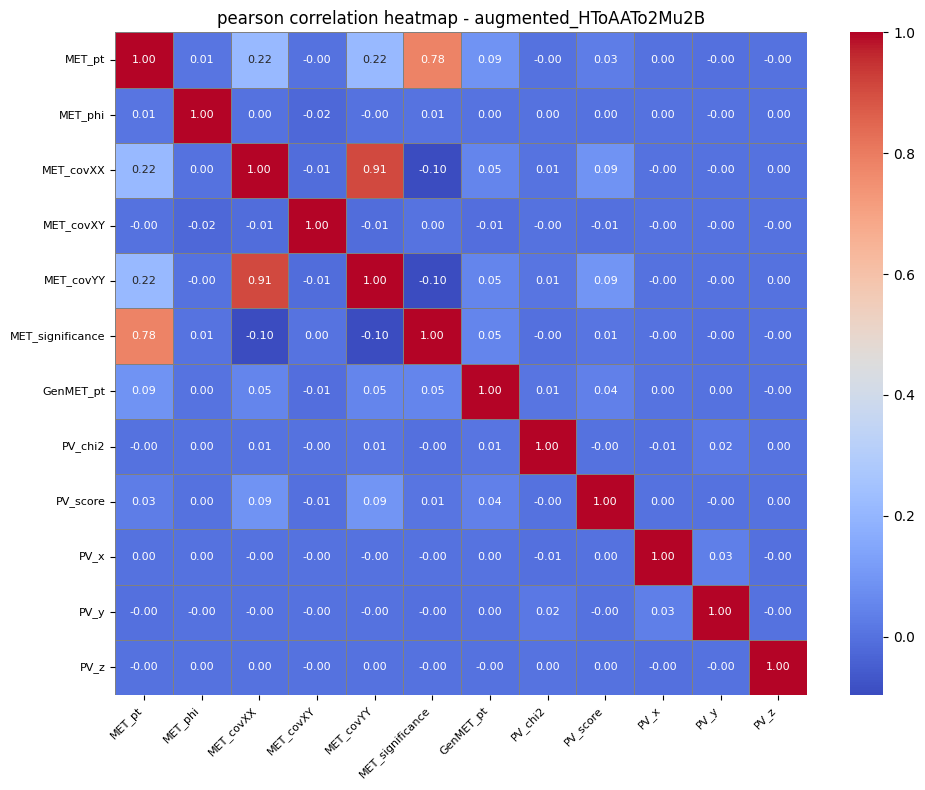

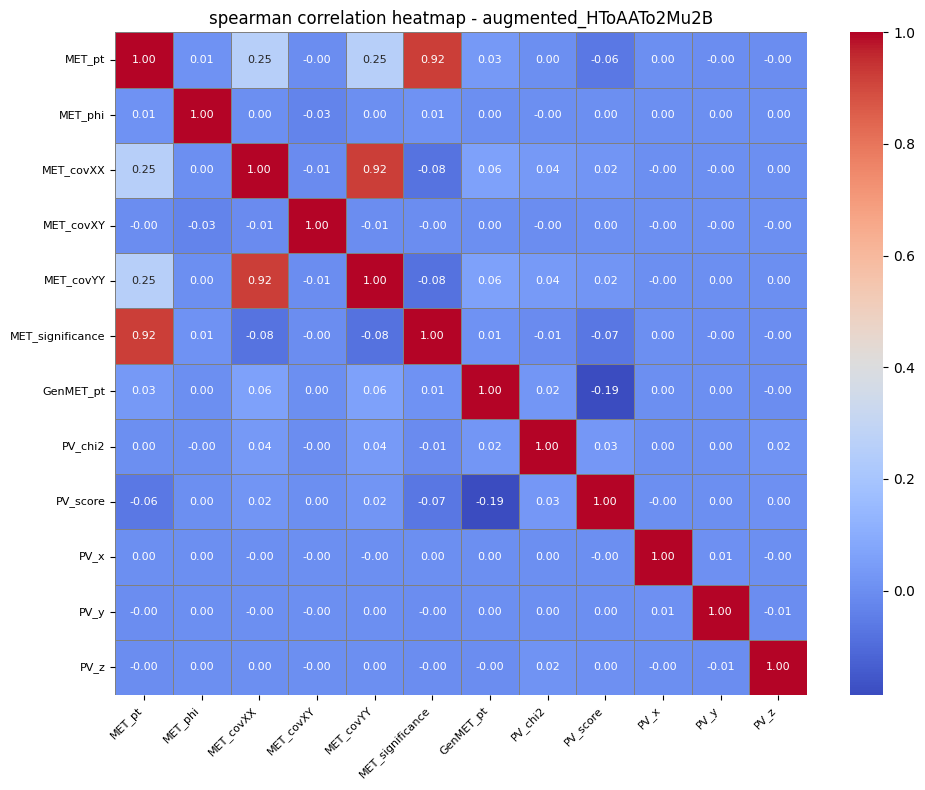

Statistics for dataset augmented_HToAATo2Mu2B:
    MET_pt:
count    400000.000000
mean         28.704001
std          17.874903
min           0.060027
25%          15.849481
50%          25.417162
75%          37.802860
max         633.434509
Name: MET_pt, dtype: float64
    GenMET_pt:
count    4.000000e+05
mean     4.169241e+00
std      6.458499e+00
min      1.122019e-14
25%      3.345122e-09
50%      1.487305e+00
75%      5.910156e+00
max      2.945000e+02
Name: GenMET_pt, dtype: float64


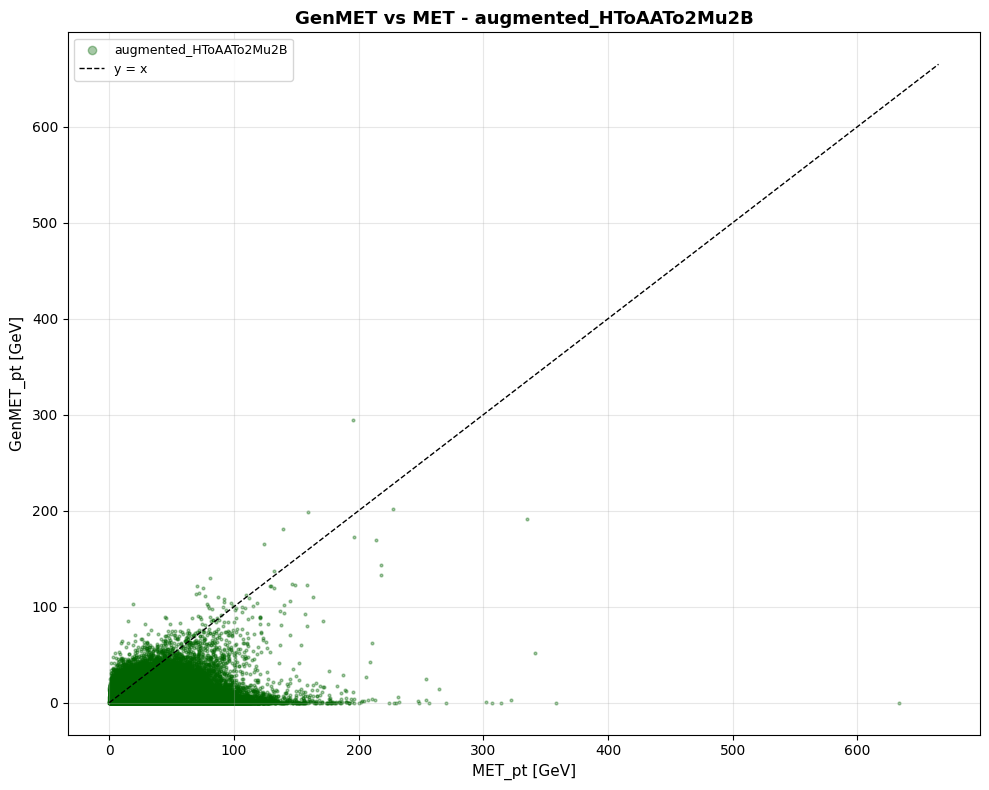

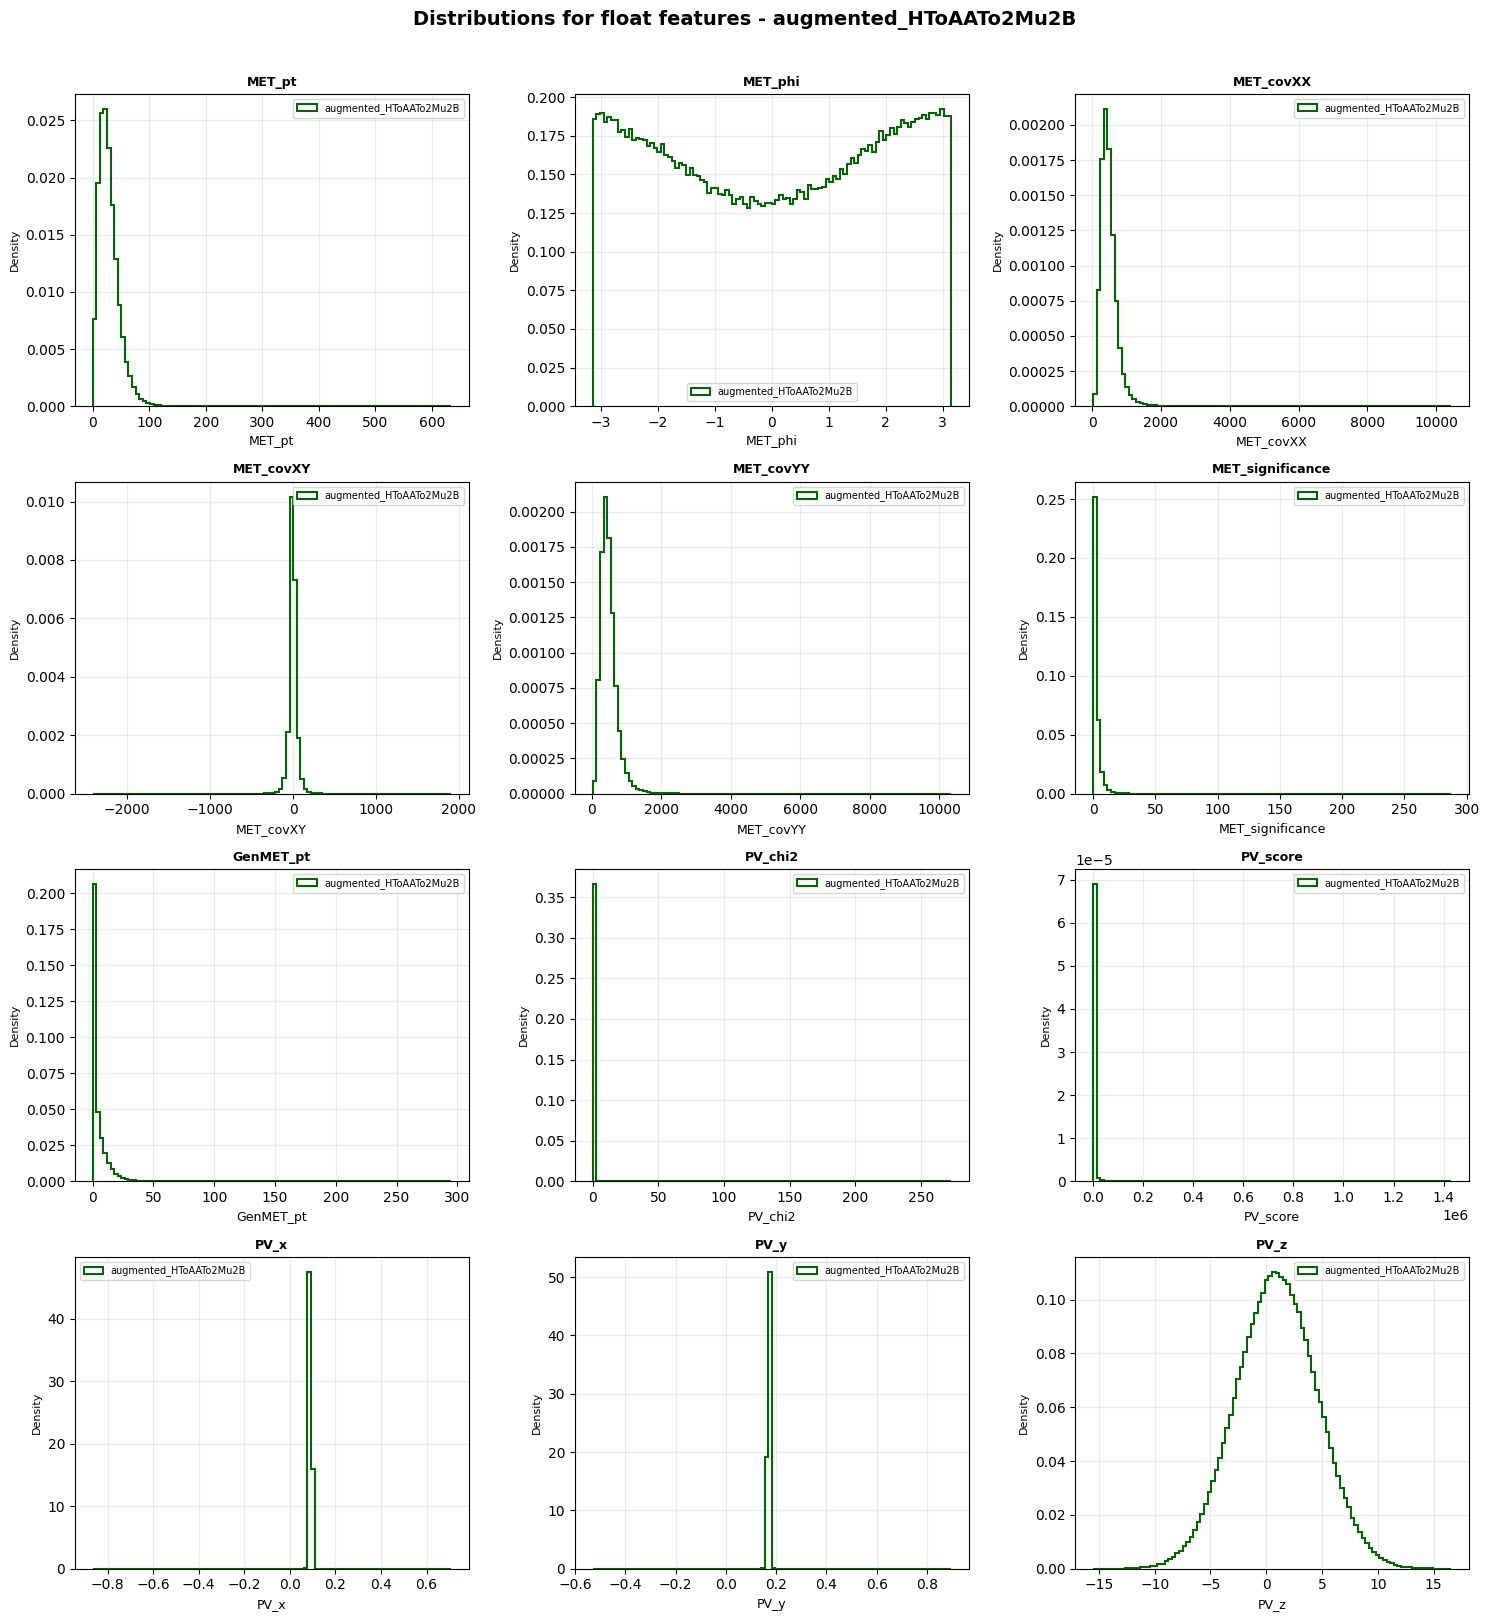

Outliers — augmented_HToAATo2Mu2B
  MET_pt                10781 outliers (2.70%)
  MET_phi                   0 outliers (0.00%)
  MET_covXX             14325 outliers (3.58%)
  MET_covXY             31499 outliers (7.87%)
  MET_covYY             14543 outliers (3.64%)
  MET_significance      27496 outliers (6.87%)
  GenMET_pt             27004 outliers (6.75%)
  PV_chi2               12678 outliers (3.17%)
  PV_score              14890 outliers (3.72%)
  PV_x                  14062 outliers (3.52%)
  PV_y                  12505 outliers (3.13%)
  PV_z                   2720 outliers (0.68%)


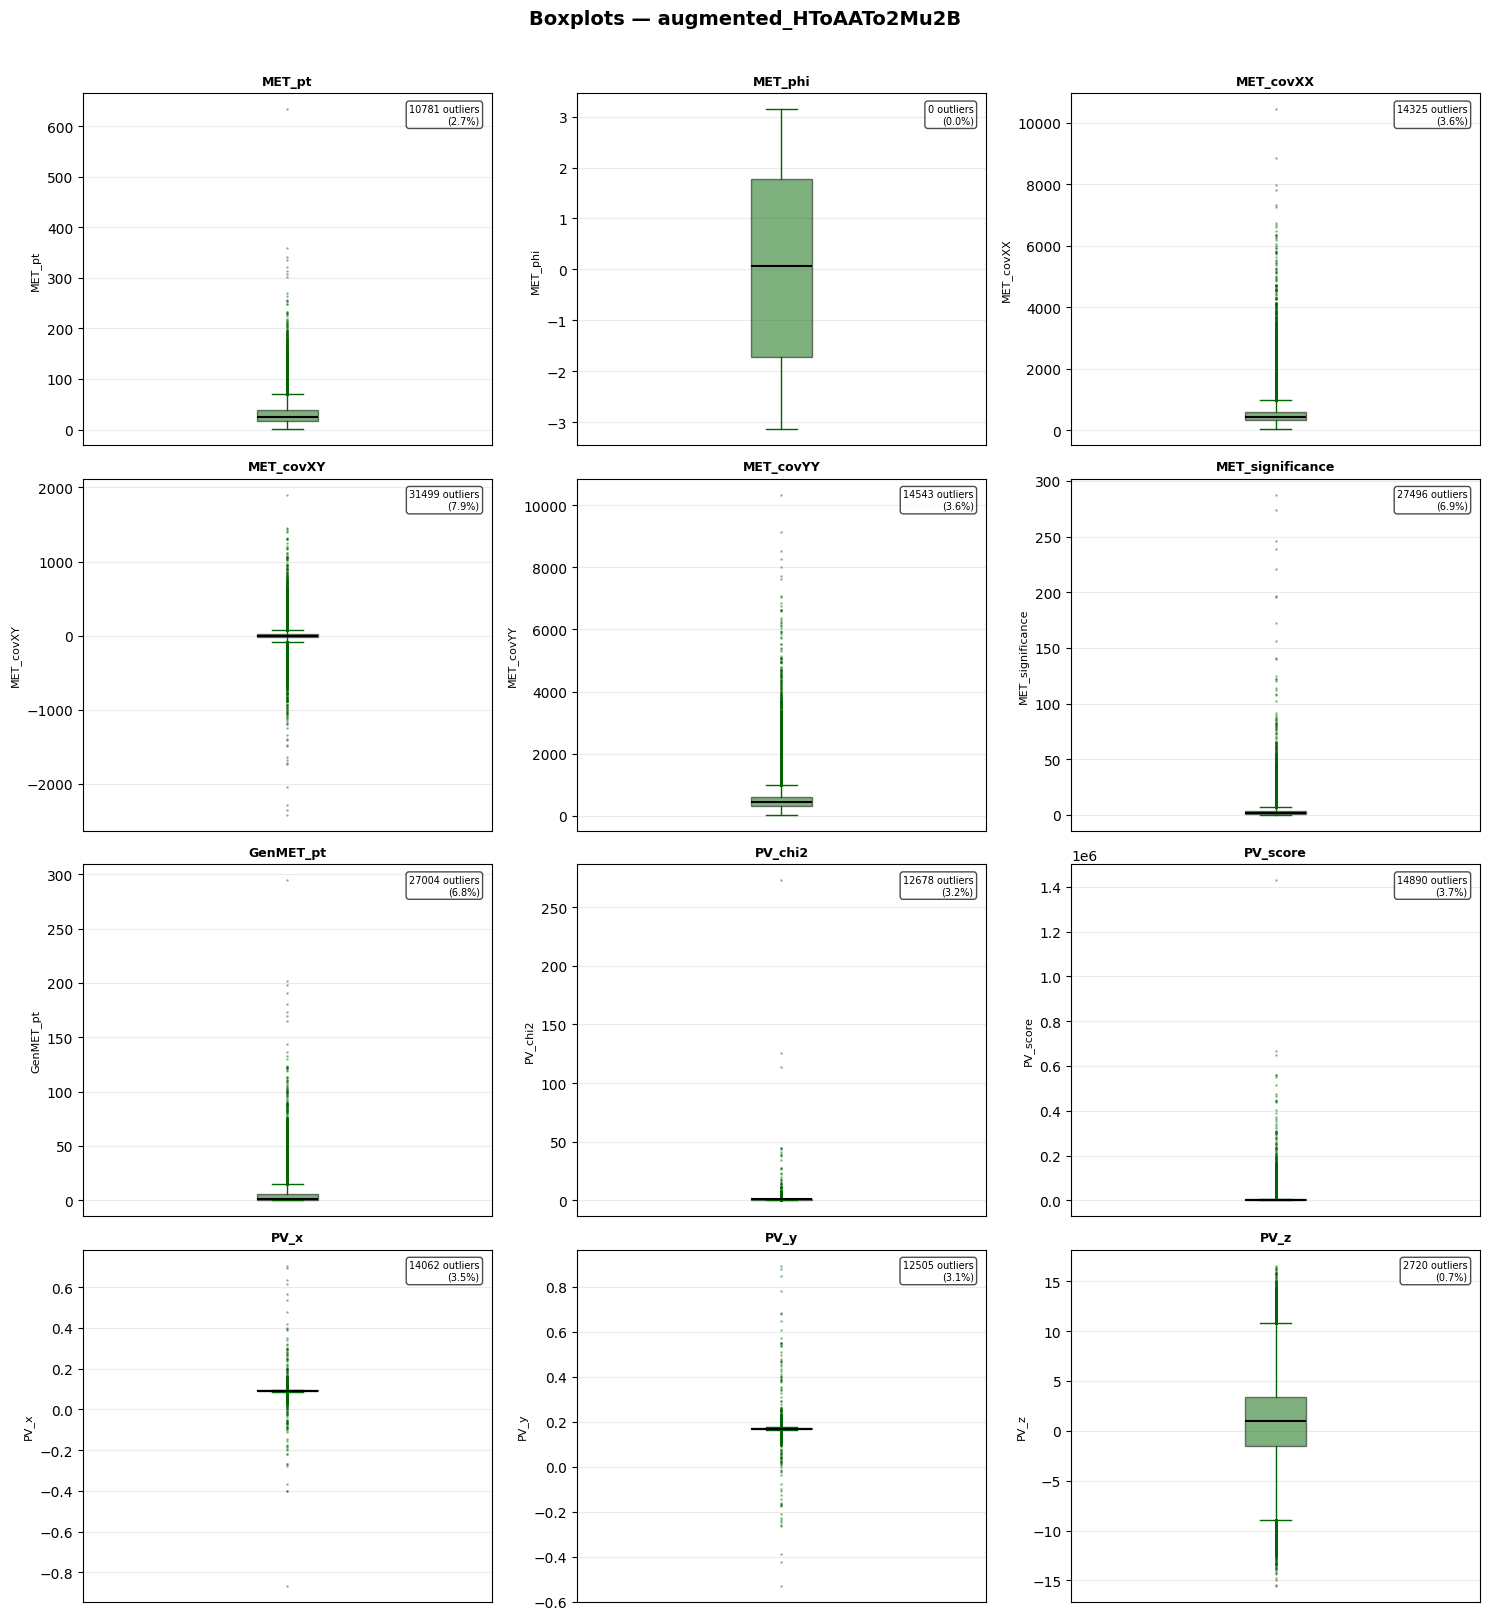

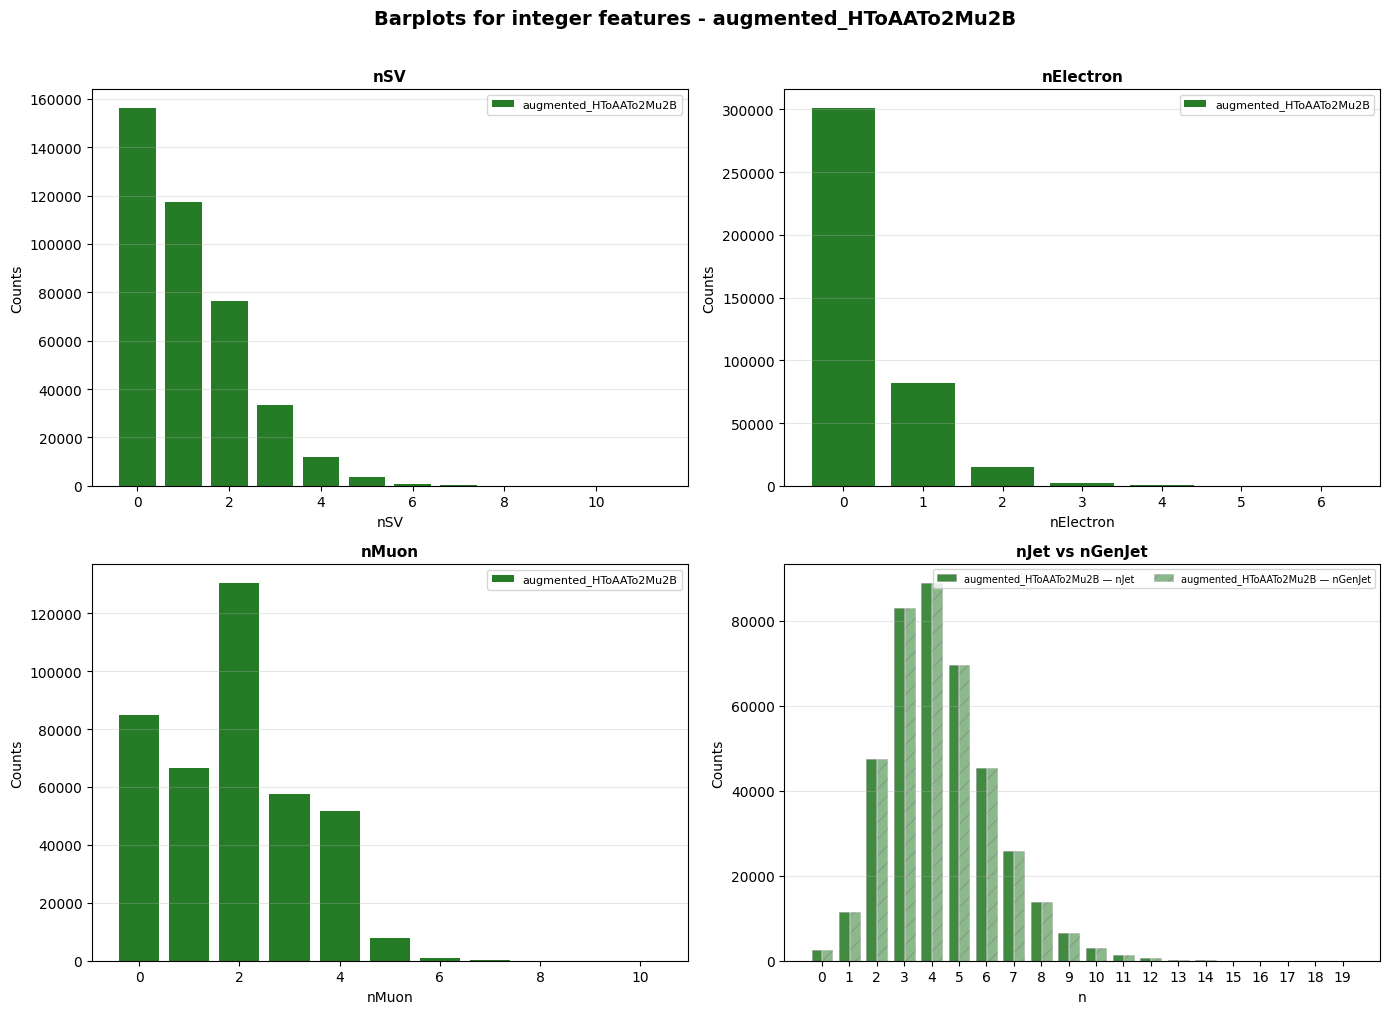

In [40]:
_correlation_heatmap(df, label)

_correlation_heatmap(df, label, method="spearman")

_scatterplot_MET(df, label=label, color=color)

_data_distributions(df, label=label, color=color)

_boxplots(df, label=label, color=color)

_data_barplots(df, label=label, color=color)